In [2]:
!pip3 install scikit-learn

In [3]:
%matplotlib inline
# Pandas is a nice utilitiy that enables some easy data manipulation, especially from a csv
import pandas as pd
# Numpy lets us work with arrays
import numpy as np
import random
# Sklearn provides various modules with a common API
from sklearn import svm, tree, neighbors, neural_network
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [4]:
RAND_STATE = 42
random.seed(RAND_STATE)
np.random.seed(RAND_STATE)

In [5]:
# Read in our csv files downloaded from Kaggle
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
train_data.columns[train_data.isna().any()].tolist()

['Age', 'Cabin', 'Embarked']

In [7]:
"""
We can do our feature engineering from here on. 

The main methods we will use will be extracting any information hidden in "useless" fields like titles from names, 
social class/survivability from the deck, and altering information already present in the family size. 


After engineering: 
Pclass, Sex, Age (try with median/NaN preservation), SibSp, Parch, Fare, Embarked (label encoded), Title (extracted + label encoded), FamilySize, IsAlone, FarePerPerson, Deck (extracted, with NaNs preserved)
"""

# Drop identifiers to avoid memorization
train_data.drop(columns=["PassengerId", "Ticket"], inplace=True)
test_data.drop(columns=["PassengerId", "Ticket"], inplace=True)

# Rename for convenience 
train_data.rename(columns={str(col): str(col.lower()) for col in train_data.columns}, inplace=True)
test_data.rename(columns={str(col): str(col.lower()) for col in test_data.columns}, inplace=True)

In [8]:
# Infer the deck level of the passenger:
train_data["deck"] = train_data["cabin"].str[0]
test_data["deck"] = test_data["cabin"].str[0]

deck_map = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6, "T": 7}
train_data["deck"] = train_data["deck"].map(deck_map)
test_data["deck"] = test_data["deck"].map(deck_map)

# Drop cabin since we are done with it 
train_data.drop(columns=["cabin"], inplace=True)
test_data.drop(columns=["cabin"], inplace=True)

test_data["deck"]

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
      ... 
413    NaN
414    2.0
415    NaN
416    NaN
417    NaN
Name: deck, Length: 418, dtype: float64

In [9]:
# Sex encoding
train_data["sex"] = train_data["sex"].map({"male": 0, "female": 1})
test_data["sex"] = test_data["sex"].map({"male": 0, "female": 1})

# Port of origin encoding
train_data["embarked"] = train_data["embarked"].fillna(train_data["embarked"].mode()[0])
test_data["embarked"] = test_data["embarked"].fillna(test_data["embarked"].mode()[0])

train_data["embarked"] = train_data["embarked"].map({"C": 0, "Q": 1, "S": 2})
test_data["embarked"] = test_data["embarked"].map({"C": 0, "Q": 1, "S": 2})

In [10]:
# Title extraction
def extract_title(df):
    df["title"] = df["name"].str.extract(r", (\w+)\.")
    df["title"] = df["title"].replace(
        ["Lady", "Countess", "Capt", "Col", "Don", "Dr",
         "Major", "Rev", "Sir", "Jonkheer", "Dona"],
        "Rare"
    )
    df["title"] = df["title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    return df

train_data = extract_title(train_data)
test_data = extract_title(test_data)

# Just to understand what we are extracting
titles = list(test_data["title"])
titles.extend(train_data["title"])

# Map to encoding
train_data["title"], title_keys = pd.factorize(train_data["title"])
test_data["title"] = test_data["title"].map(dict(zip(title_keys, range(len(title_keys)))))

train_data["title"] = train_data["title"].replace(-1, np.nan)
test_data["title"] = test_data["title"].replace(-1, np.nan)
set(list(train_data["title"])), train_data["title"]

({0.0, 1.0, 2.0, 3.0, 4.0, nan},
 0      0.0
 1      1.0
 2      2.0
 3      1.0
 4      0.0
       ... 
 886    4.0
 887    2.0
 888    2.0
 889    0.0
 890    0.0
 Name: title, Length: 891, dtype: float64)

In [11]:
# Family sizing data
train_data["fam_size"] = train_data["sibsp"] + train_data["parch"] + 1
test_data["fam_size"] = test_data["sibsp"] + test_data["parch"] + 1

# Is alone passenger
train_data["is_alone"] = (train_data["fam_size"] == 1).astype(int)
test_data["is_alone"] = (test_data["fam_size"] == 1).astype(int)

train_data["fam_size"], train_data["is_alone"]


(0      2
 1      2
 2      1
 3      2
 4      1
       ..
 886    1
 887    1
 888    4
 889    1
 890    1
 Name: fam_size, Length: 891, dtype: int64,
 0      0
 1      0
 2      1
 3      0
 4      1
       ..
 886    1
 887    1
 888    0
 889    1
 890    1
 Name: is_alone, Length: 891, dtype: int64)

In [12]:
# Fare per person data - speculative in signal
train_data["fpp"] = train_data["fare"] / train_data["fam_size"]
test_data["fpp"] = test_data["fare"] / test_data["fam_size"]

train_data["fpp"]

0       3.62500
1      35.64165
2       7.92500
3      26.55000
4       8.05000
         ...   
886    13.00000
887    30.00000
888     5.86250
889    30.00000
890     7.75000
Name: fpp, Length: 891, dtype: float64

In [13]:
# Lastly, drop names to avoid memorization
train_data.drop(columns=["name"], inplace=True)
test_data.drop(columns=["name"], inplace=True)

In [14]:
train_data.describe(), train_data.columns

(         survived      pclass         sex         age       sibsp       parch  \
 count  891.000000  891.000000  891.000000  714.000000  891.000000  891.000000   
 mean     0.383838    2.308642    0.352413   29.699118    0.523008    0.381594   
 std      0.486592    0.836071    0.477990   14.526497    1.102743    0.806057   
 min      0.000000    1.000000    0.000000    0.420000    0.000000    0.000000   
 25%      0.000000    2.000000    0.000000   20.125000    0.000000    0.000000   
 50%      0.000000    3.000000    0.000000   28.000000    0.000000    0.000000   
 75%      1.000000    3.000000    1.000000   38.000000    1.000000    0.000000   
 max      1.000000    3.000000    1.000000   80.000000    8.000000    6.000000   
 
              fare    embarked        deck       title    fam_size    is_alone  \
 count  891.000000  891.000000  204.000000  890.000000  891.000000  891.000000   
 mean    32.204208    1.536476    2.392157    0.791011    1.904602    0.602694   
 std     49.69

In [15]:
# Build train/test split:
X_train = train_data.loc[:, train_data.columns != "survived"]
y_train = train_data.loc[:, "survived"]

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.33, random_state=RAND_STATE)


In [16]:
# Fill missing values in X_train and X_test
train_nan_map = {
    'age': X_train['age'].median(),
    'fare': X_train['fare'].median(),
    'deck': X_train['deck'].median(),
    'fpp': X_train['fpp'].median() if 'fpp' in X_train.columns else 0,
    'title': X_train['title'].mode()[0] if 'title' in X_train.columns else 0
}

test_nan_map = {
    'age': X_test['age'].median(),
    'fare': X_test['fare'].median(),
    'deck': X_test['deck'].median(),
    'fpp': X_test['fpp'].median() if 'fpp' in X_test.columns else 0,
    'title': X_test['title'].mode()[0] if 'title' in X_test.columns else 0
}

X_train.fillna(train_nan_map, inplace=True)
X_test.fillna(test_nan_map, inplace=True)

# Verify no missing values remain
print(X_train.isna().sum())
print(X_test.isna().sum())


pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
deck        0
title       0
fam_size    0
is_alone    0
fpp         0
dtype: int64
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
deck        0
title       0
fam_size    0
is_alone    0
fpp         0
dtype: int64


In [17]:
X_train.describe(), X_test.describe(), y_train.describe(), y_test.describe()

(           pclass         sex         age       sibsp       parch        fare  \
 count  596.000000  596.000000  596.000000  596.000000  596.000000  596.000000   
 mean     2.337248    0.345638   29.223859    0.577181    0.374161   31.912786   
 std      0.823207    0.475975   12.958999    1.229504    0.807072   51.480961   
 min      1.000000    0.000000    0.420000    0.000000    0.000000    0.000000   
 25%      2.000000    0.000000   22.000000    0.000000    0.000000    7.925000   
 50%      3.000000    0.000000   28.000000    0.000000    0.000000   14.454200   
 75%      3.000000    1.000000   35.000000    1.000000    0.000000   31.275000   
 max      3.000000    1.000000   80.000000    8.000000    6.000000  512.329200   
 
          embarked        deck       title    fam_size    is_alone         fpp  
 count  596.000000  596.000000  596.000000  596.000000  596.000000  596.000000  
 mean     1.558725    2.097315    0.768456    1.951342    0.604027   19.957290  
 std      0.77453

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data, transform both training and test splits
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
# Initialize KNN again
knn = KNeighborsClassifier(n_neighbors=8, weights='uniform', algorithm='auto', 
                           leaf_size=1, p=1)

# Fit on scaled training data
knn.fit(X_train_scaled, y_train)

# Predict on scaled test data
y_pred = knn.predict(X_test_scaled)

# Check accuracy again
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on test split after scaling:", accuracy)

Accuracy on test split after scaling: 0.8305084745762712


In [20]:
# Prepare Kaggle test data
test_data_filled = test_data.fillna({
    'age': train_data['age'].median(),
    'fare': train_data['fare'].median(),
    'deck': train_data['deck'].median(),
    'fpp': train_data['fpp'].median(),
    'title': train_data['title'].mode()[0]
})

# Scale Kaggle test features
X_test_kaggle_scaled = scaler.transform(test_data_filled)

# Predict on Kaggle test set
y_pred_kaggle = knn.predict(X_test_kaggle_scaled)

# Create submission file
submission = pd.DataFrame({
    "PassengerId": pd.read_csv('test.csv')["PassengerId"],  # original test IDs
    "Survived": y_pred_kaggle
})

submission.to_csv("predictions.csv", index=False)
print("Submission file created!")

Submission file created!


In [21]:
# Predict on the test split
y_pred = knn.predict(X_test_scaled)

y_truth = y_test


In [22]:
accuracy = accuracy_score(y_truth, y_pred)
print("Accuracy on test split:", accuracy)

tn, fp, fn, tp = confusion_matrix(y_truth, y_pred).ravel()
print("Confusion Matrix")
print(confusion_matrix(y_truth, y_pred, labels=[0, 1]))
print("")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

Accuracy on test split: 0.8305084745762712
Confusion Matrix
[[161  14]
 [ 36  84]]

True Negatives 161
False Positives 14
False Negatives 36
True Positives 84


Confusion matrix, without normalization
[[161  14]
 [ 36  84]]


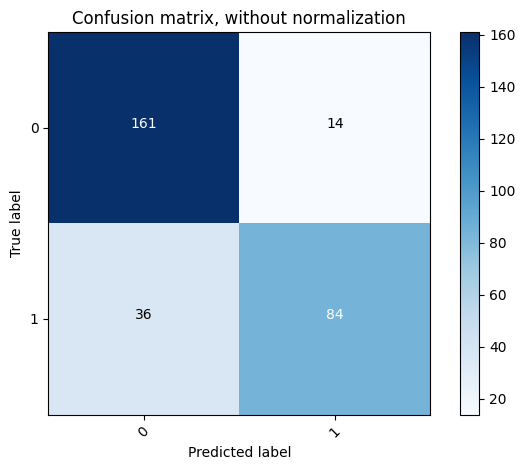

In [23]:
import itertools
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


# Compute confusion matrix
cnf_matrix = confusion_matrix(y_truth, y_pred)
class_names=['0', '1']
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names,
                      title='Confusion matrix, without normalization')

plt.show()

In [24]:
test_original = pd.read_csv('test.csv')  # just to get PassengerId

In [25]:
sub = pd.DataFrame({
    "PassengerId": test_original["PassengerId"],
    "Survived": y_pred
})


ValueError: array length 295 does not match index length 418